In [1]:
!pip install segmentation-models-pytorch
!pip install albumentations
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    jaccard_score
)

from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
images_dir = "/content/drive/MyDrive/MeltPoolDataset/images"

masks_dir = "/content/drive/MyDrive/MeltPoolDataset/masks"

In [11]:
class MeltPoolDataset(Dataset):

    def __init__(self, images_dir, masks_dir):

        self.images_dir = images_dir
        self.masks_dir = masks_dir

        self.images = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(mask, (256,256))

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [12]:
dataset = MeltPoolDataset(images_dir, masks_dir)

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("Dataset Loaded Successfully")
print("Total Images:", len(dataset))

Dataset Loaded Successfully
Total Images: 92


In [13]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [16]:
loss_fn = smp.losses.DiceLoss(mode='binary')

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [17]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")


Epoch 1, Loss: 21.013973832130432
Epoch 2, Loss: 20.188695430755615
Epoch 3, Loss: 19.48399245738983
Epoch 4, Loss: 18.78854513168335
Epoch 5, Loss: 18.067837297916412
Epoch 6, Loss: 17.284661293029785
Epoch 7, Loss: 16.443650782108307
Epoch 8, Loss: 15.488089501857758
Epoch 9, Loss: 14.483048379421234
Epoch 10, Loss: 13.398504078388214
Epoch 11, Loss: 12.333426833152771
Epoch 12, Loss: 11.20937693119049
Epoch 13, Loss: 10.181181609630585
Epoch 14, Loss: 9.174529075622559
Epoch 15, Loss: 8.218063294887543
Epoch 16, Loss: 7.474164426326752
Epoch 17, Loss: 6.64975243806839
Epoch 18, Loss: 5.913605690002441
Epoch 19, Loss: 5.244650363922119
Epoch 20, Loss: 4.781226754188538


In [18]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/unet_model.pth"
)

In [19]:
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

In [20]:
deeplab_model.to(device)

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [21]:
optimizer2 = torch.optim.Adam(
    deeplab_model.parameters(),
    lr=0.0001
)

In [22]:
epochs = 20

for epoch in range(epochs):

    deeplab_model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = deeplab_model(images)

        loss = loss_fn(preds, masks)

        optimizer2.zero_grad()

        loss.backward()

        optimizer2.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")


Epoch 1, Loss: 20.7744979262352
Epoch 2, Loss: 19.5543292760849
Epoch 3, Loss: 17.965856194496155
Epoch 4, Loss: 16.175000071525574
Epoch 5, Loss: 14.406010746955872
Epoch 6, Loss: 12.614810347557068
Epoch 7, Loss: 10.936738848686218
Epoch 8, Loss: 9.363352298736572
Epoch 9, Loss: 7.983720600605011
Epoch 10, Loss: 6.844634473323822
Epoch 11, Loss: 5.9456310868263245
Epoch 12, Loss: 5.243352055549622
Epoch 13, Loss: 4.611716985702515
Epoch 14, Loss: 4.169577956199646
Epoch 15, Loss: 3.8633942008018494
Epoch 16, Loss: 3.5165905356407166
Epoch 17, Loss: 3.2868205308914185
Epoch 18, Loss: 3.1102534532546997
Epoch 19, Loss: 2.8609499335289
Epoch 20, Loss: 2.7075381875038147


In [23]:
torch.save(
    deeplab_model.state_dict(),
    "/content/drive/MyDrive/deeplab_model.pth"
)

In [33]:
sample_img = cv2.imread(
    "/content/drive/MyDrive/MeltPoolDataset/images/frame_90.png"
)

sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

img = cv2.resize(sample_img, (256,256))

input_img = img / 255.0

input_img = torch.tensor(input_img).permute(2,0,1).unsqueeze(0).float()

input_img = input_img.to(device)

In [34]:
model.eval()

with torch.no_grad():

    pred = model(input_img)

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.5).astype(np.uint8)

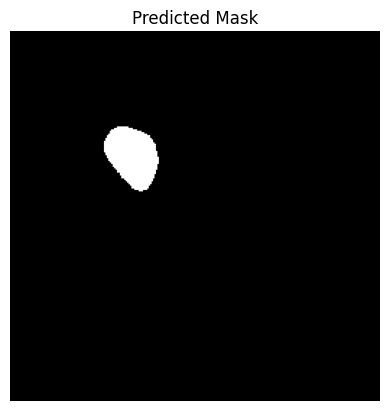

In [35]:
plt.imshow(pred, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')
plt.show()

In [36]:
true_mask = cv2.imread(
    "/content/drive/MyDrive/MeltPoolDataset/masks/frame_90.png",
    0
)

true_mask = cv2.resize(true_mask, (256,256))

true_mask = (true_mask > 0).astype(np.uint8)

In [37]:
y_true = true_mask.flatten()

y_pred = pred.flatten()

In [38]:
iou = jaccard_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)

dice = (2*np.sum(y_true*y_pred)) / (
    np.sum(y_true) + np.sum(y_pred)
)

In [39]:
print("IoU:", iou)

print("Dice Score:", dice)

print("Precision:", precision)

print("Recall:", recall)

print("Accuracy:", accuracy)

IoU: 0.8315935977731385
Dice Score: 0.9080547112462006
Precision: 1.0
Recall: 0.8315935977731385
Accuracy: 0.996307373046875


In [59]:
deeplab_model.eval()

with torch.no_grad():

    pred2 = deeplab_model(input_img)

pred2 = pred2.squeeze().cpu().numpy()

pred2 = (pred2 > 0.5).astype(np.uint8)

In [60]:
y_pred2 = pred2.flatten()

In [61]:
iou2 = jaccard_score(y_true, y_pred2)

precision2 = precision_score(y_true, y_pred2)

recall2 = recall_score(y_true, y_pred2)

accuracy2 = accuracy_score(y_true, y_pred2)

dice2 = (2*np.sum(y_true*y_pred2)) / (
    np.sum(y_true) + np.sum(y_pred2)
)

In [62]:
print("DeepLab IoU:", iou2)

print("DeepLab Dice:", dice2)

print("DeepLab Precision:", precision2)

print("DeepLab Recall:", recall2)

print("DeepLab Accuracy:", accuracy2)

DeepLab IoU: 0.8236914600550964
DeepLab Dice: 0.9033232628398792
DeepLab Precision: 0.9876135425268373
DeepLab Recall: 0.8322894919972165
DeepLab Accuracy: 0.99609375


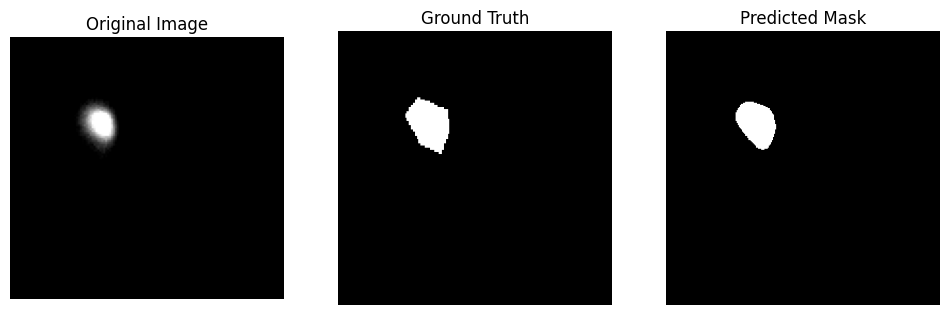

In [40]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [41]:
mask_uint8 = (pred * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    mask_uint8,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour = max(contours, key=cv2.contourArea)

In [42]:
area = cv2.contourArea(contour)
print("Area:", area)

Area: 1136.5


In [43]:
perimeter = cv2.arcLength(contour, True)
print("Perimeter:", perimeter)

Perimeter: 134.4680358171463


In [45]:
x, y, w, h = cv2.boundingRect(contour)

width = w
length = h

print("Width:", width)
print("Length:", length)

Width: 38
Length: 45


In [46]:
aspect_ratio = width / length

print("Aspect Ratio:", aspect_ratio)

Aspect Ratio: 0.8444444444444444


In [47]:
ellipse = cv2.fitEllipse(contour)

(center),(MA,ma),angle = ellipse

eccentricity = np.sqrt(1 - (MA/ma)**2)

print("Eccentricity:", eccentricity)

Eccentricity: 0.7241349133993734


In [49]:
compactness = (4*np.pi*area)/(perimeter**2)

print("Compactness:", compactness)

Compactness: 0.7898437424119172


In [50]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [51]:
mean_intensity = np.mean(gray[pred==1])

print("Mean Intensity:", mean_intensity)

Mean Intensity: 147.51046025104603


In [52]:
max_intensity = np.max(gray[pred==1])

print("Max Intensity:", max_intensity)

Max Intensity: 255


In [53]:
variance = np.var(gray[pred==1])

print("Intensity Variance:", variance)

Intensity Variance: 7143.1670453948645


In [54]:
grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1)

gradient = np.sqrt(grad_x**2 + grad_y**2)

thermal_gradient = np.mean(gradient)

print("Thermal Gradient:", thermal_gradient)

Thermal Gradient: 3.0266574134306965


In [55]:
roughness = perimeter / (2*np.sqrt(np.pi*area))

print("Boundary Roughness:", roughness)

Boundary Roughness: 1.1251991854866539


In [57]:
curvature = len(contour)

print("Curvature:", curvature)

Curvature: 72


In [58]:
flipped = cv2.flip(pred, 1)

symmetry = np.sum(pred == flipped)/pred.size

print("Symmetry:", symmetry)

Symmetry: 0.963531494140625


| Metric     | U-Net  | DeepLabV3+
| ---------- | ------ | ----------
| IoU        | 0.8316 | 0.8237
| Dice Score | 0.9081 | 0.9033
| Precision  | 1.0000 | 0.9876     
| Recall     | 0.8316 | 0.8323     
| Accuracy   | 0.9963 | 0.9961     


Experimental results show that U-Net achieved better segmentation performance compared to DeepLabV3+. U-Net obtained higher IoU, Dice Score, Precision, and Accuracy values. DeepLabV3+ achieved slightly better Recall, indicating better detection of some melt pool regions, but overall U-Net provided more accurate and stable segmentation results for the melt pool dataset.